# 04_results.ipynb — Figures and Final Analysis

**Purpose:** Load all saved results and generate all 10 paper figures at 300 dpi.

**Inputs:** `results/loso_results.pkl`, `results/importance_agg.pkl`, `results/importance_corr.pkl`, `results/null_results.pkl`, `results/svm_importance.pkl`, `results/within_subject.pkl`, `results/y.npy`, `results/subject_ids.npy`, `results/feature_names.npy`

**Outputs:** `results/figures/figure_{1-10}.png`

All importance claims use within-subject SVM as the primary source. LOSO importance is used only for RQ5 cross-condition comparison (Figure 8). LOSO SVM band-level importance is excluded from all figures.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from features import CHANNEL_NAMES, ELECTRODE_REGIONS, FAA_PAIRS, BANDS, N_BP_FEATURES
from models import TARGETS, BAND_NAMES, CONFIGS, CORR_KEYS

Path('../results/figures').mkdir(exist_ok=True)

# ── Load all results ───────────────────────────────────────────────────────────
with open('../results/loso_results.pkl',   'rb') as f: loso    = pickle.load(f)
with open('../results/importance_agg.pkl', 'rb') as f: rf_agg  = pickle.load(f)
with open('../results/importance_corr.pkl','rb') as f: rf_corr = pickle.load(f)
with open('../results/null_results.pkl',   'rb') as f: null    = pickle.load(f)
with open('../results/svm_importance.pkl', 'rb') as f: svm_imp = pickle.load(f)
with open('../results/within_subject.pkl', 'rb') as f: ws      = pickle.load(f)

y           = np.load('../results/y.npy')
subject_ids = np.load('../results/subject_ids.npy')
feat_names  = list(np.load('../results/feature_names.npy'))

# ── Shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'axes.spines.top': False, 'axes.spines.right': False,
})
TARGET_NAMES = list(TARGETS.keys())
COLORS = {'valence': '#4878CF', 'arousal': '#6ACC65', 'dominance': '#D65F5F'}
DIM_COLORS = [COLORS[t] for t in TARGET_NAMES]

def save(name):
    plt.savefig(f'../results/figures/{name}.png', bbox_inches='tight')
    plt.show()
    print(f'Saved: {name}.png')

print('All results loaded.')

All results loaded.


## Figure 1 — Class balance

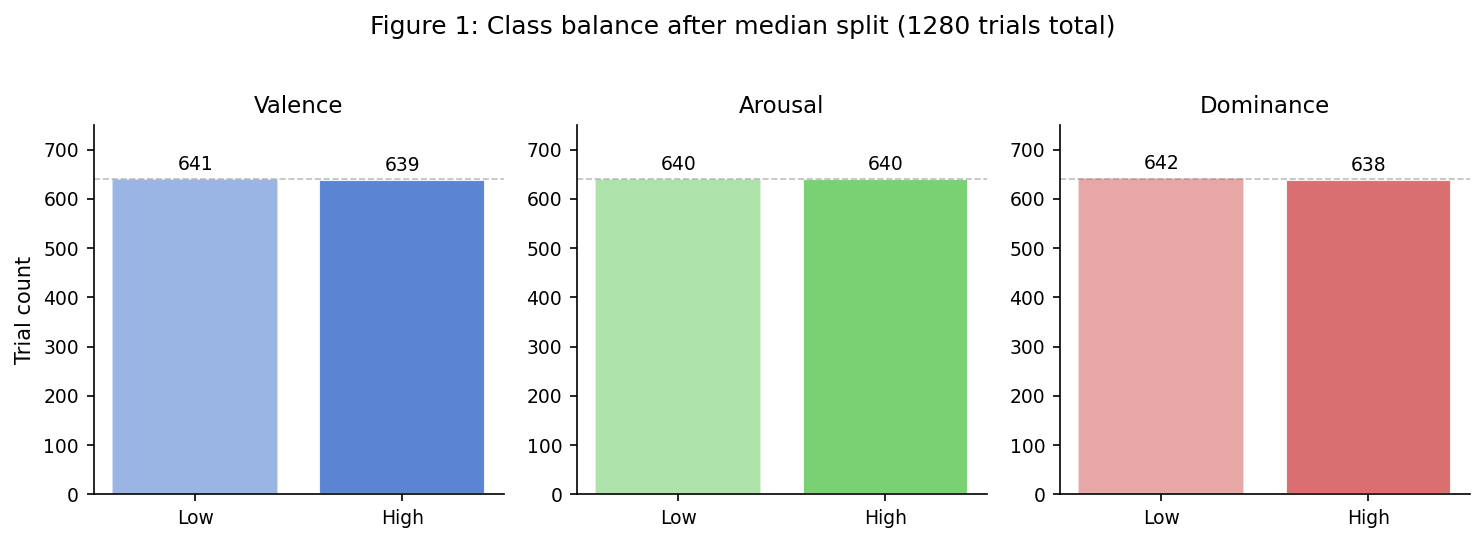

Saved: figure_1_class_balance.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

for ax, (target, col) in zip(axes, TARGETS.items()):
    median = np.median(y[:, col])
    n_low  = int((y[:, col] <= median).sum())
    n_high = int((y[:, col] >  median).sum())

    b_low  = ax.bar(['Low'],  [n_low],  color=COLORS[target], alpha=0.55, edgecolor='white')
    b_high = ax.bar(['High'], [n_high], color=COLORS[target], alpha=0.90, edgecolor='white')

    ax.set_title(target.capitalize())
    ax.set_ylabel('Trial count' if target == 'valence' else '')
    ax.set_ylim(0, 750)
    ax.text(0, n_low  + 10, str(n_low),  ha='center', va='bottom', fontsize=9)
    ax.text(1, n_high + 10, str(n_high), ha='center', va='bottom', fontsize=9)
    ax.axhline(640, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

fig.suptitle('Figure 1: Class balance after median split (1280 trials total)', y=1.02)
plt.tight_layout()
save('figure_1_class_balance')

## Figure 2 — Band power heatmap: high vs low valence and arousal

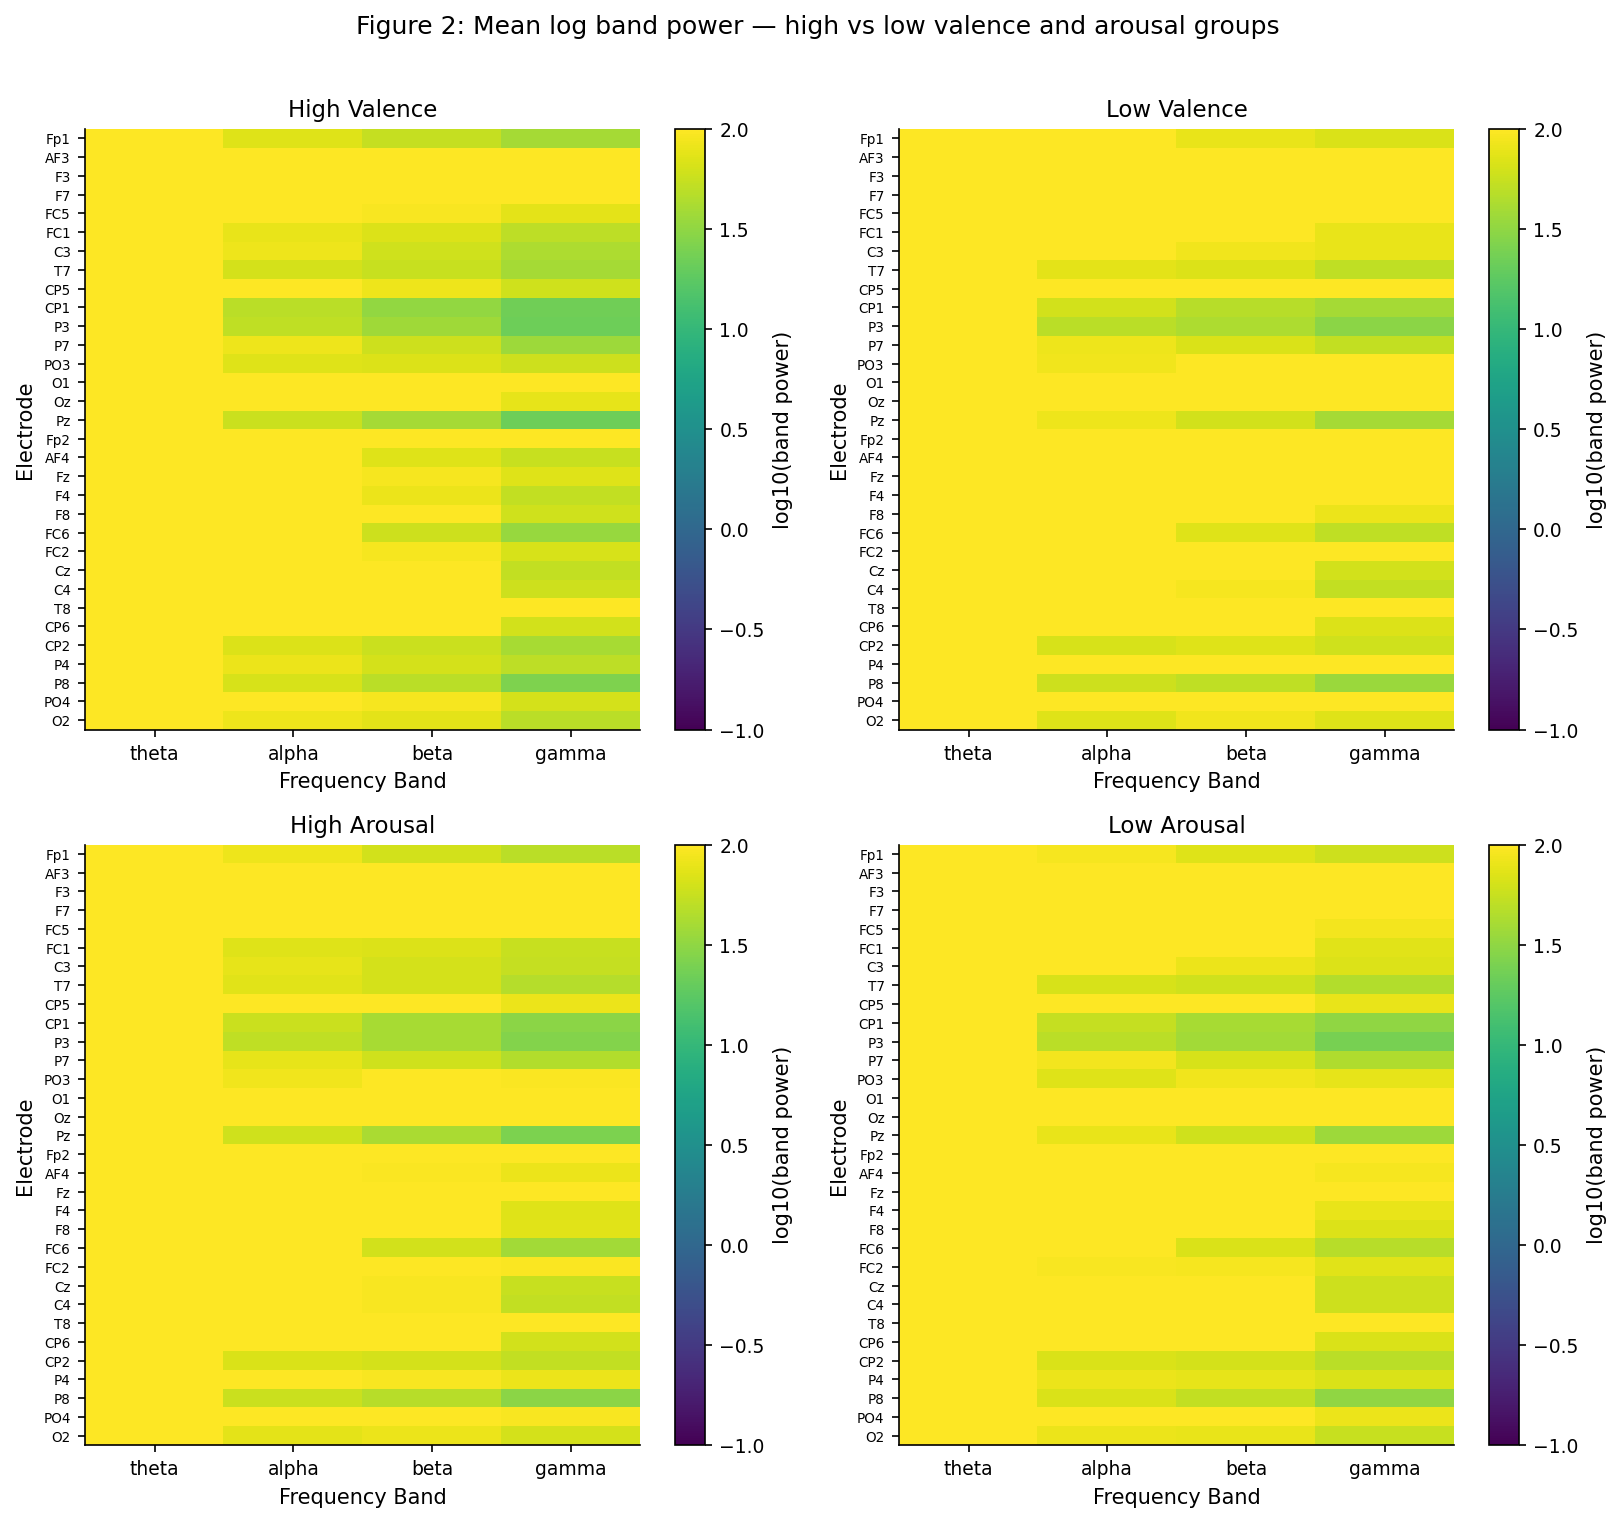

Saved: figure_2_band_power_heatmap.png


In [4]:
X_features = np.load('../results/X_features.npy')
bp_all = X_features[:, :N_BP_FEATURES].reshape(len(X_features), 32, 4)  # (1280, 32, 4)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
titles = ['High Valence', 'Low Valence', 'High Arousal', 'Low Arousal']

for i, (target_name, split) in enumerate([
    ('valence', 'high'), ('valence', 'low'),
    ('arousal', 'high'), ('arousal', 'low'),
]):
    col    = TARGETS[target_name]
    median = np.median(y[:, col])
    mask   = (y[:, col] > median) if split == 'high' else (y[:, col] <= median)
    matrix = bp_all[mask].mean(axis=0)  # (32, 4)

    ax = axes[i // 2, i % 2]
    im = ax.imshow(np.log10(matrix + 1e-10), aspect='auto',
                   cmap='viridis', vmin=-1, vmax=2)
    ax.set_title(titles[i])
    ax.set_xticks(range(4))
    ax.set_xticklabels(BAND_NAMES)
    ax.set_yticks(range(32))
    ax.set_yticklabels(CHANNEL_NAMES, fontsize=6.5)
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Electrode')
    plt.colorbar(im, ax=ax, label='log10(band power)')

fig.suptitle('Figure 2: Mean log band power — high vs low valence and arousal groups', y=1.01)
plt.tight_layout()
save('figure_2_band_power_heatmap')

## Figure 3 — Within-subject vs LOSO accuracy (RQ3)

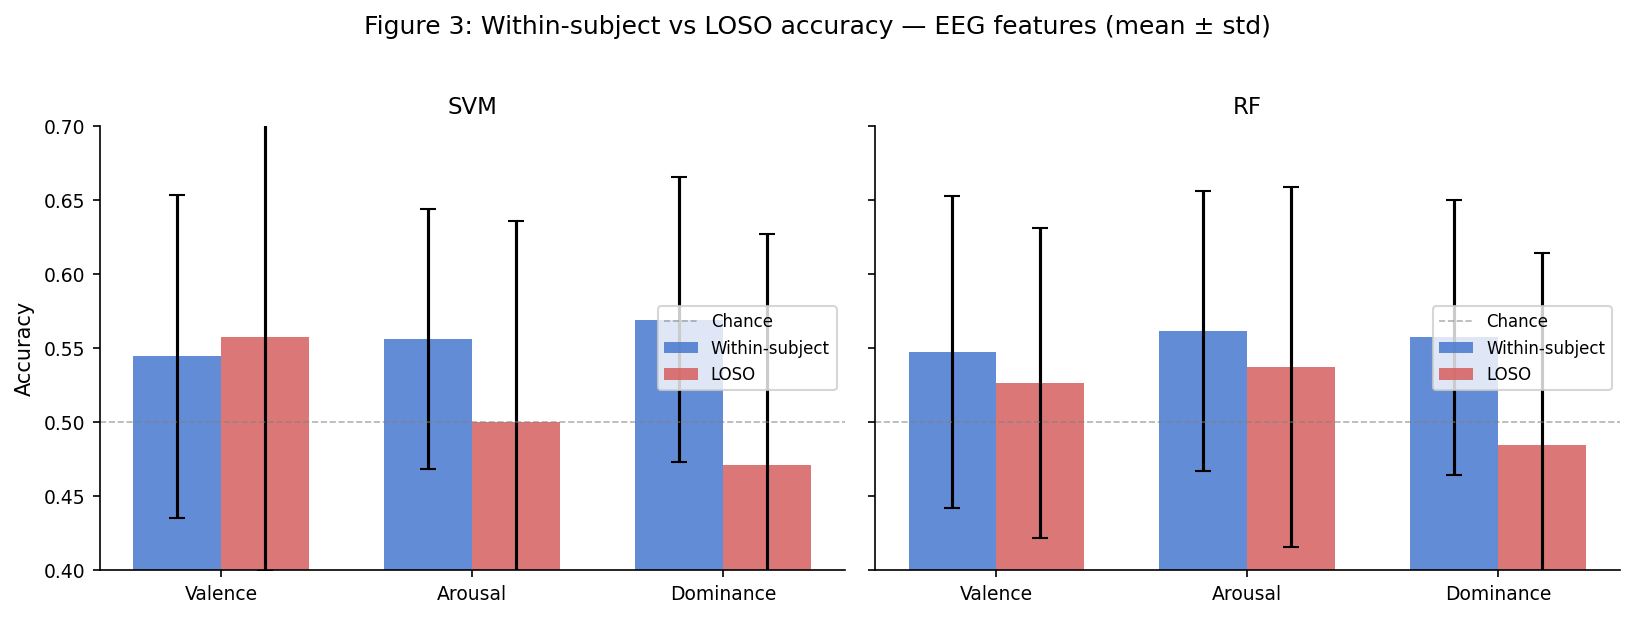

Saved: figure_3_accuracy_comparison.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, model in zip(axes, ('svm', 'rf')):
    x     = np.arange(len(TARGET_NAMES))
    width = 0.35

    ws_means  = [np.nanmean(ws['metrics'][t][model]['acc'])  for t in TARGET_NAMES]
    ws_stds   = [np.nanstd(ws['metrics'][t][model]['acc'])   for t in TARGET_NAMES]
    lo_means  = [np.mean(loso['metrics'][t]['eeg'][model]['acc']) for t in TARGET_NAMES]
    lo_stds   = [np.std(loso['metrics'][t]['eeg'][model]['acc'])  for t in TARGET_NAMES]

    b1 = ax.bar(x - width/2, ws_means, width, yerr=ws_stds, capsize=4,
                label='Within-subject', color='#4878CF', alpha=0.85)
    b2 = ax.bar(x + width/2, lo_means, width, yerr=lo_stds, capsize=4,
                label='LOSO', color='#D65F5F', alpha=0.85)

    ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6, label='Chance')
    ax.set_xticks(x)
    ax.set_xticklabels([t.capitalize() for t in TARGET_NAMES])
    ax.set_title(model.upper())
    ax.set_ylabel('Accuracy' if model == 'svm' else '')
    ax.set_ylim(0.40, 0.70)
    ax.legend(fontsize=8)

fig.suptitle('Figure 3: Within-subject vs LOSO accuracy — EEG features (mean ± std)', y=1.02)
plt.tight_layout()
save('figure_3_accuracy_comparison')

## Figure 4 — Topographic importance maps (within-subject SVM)

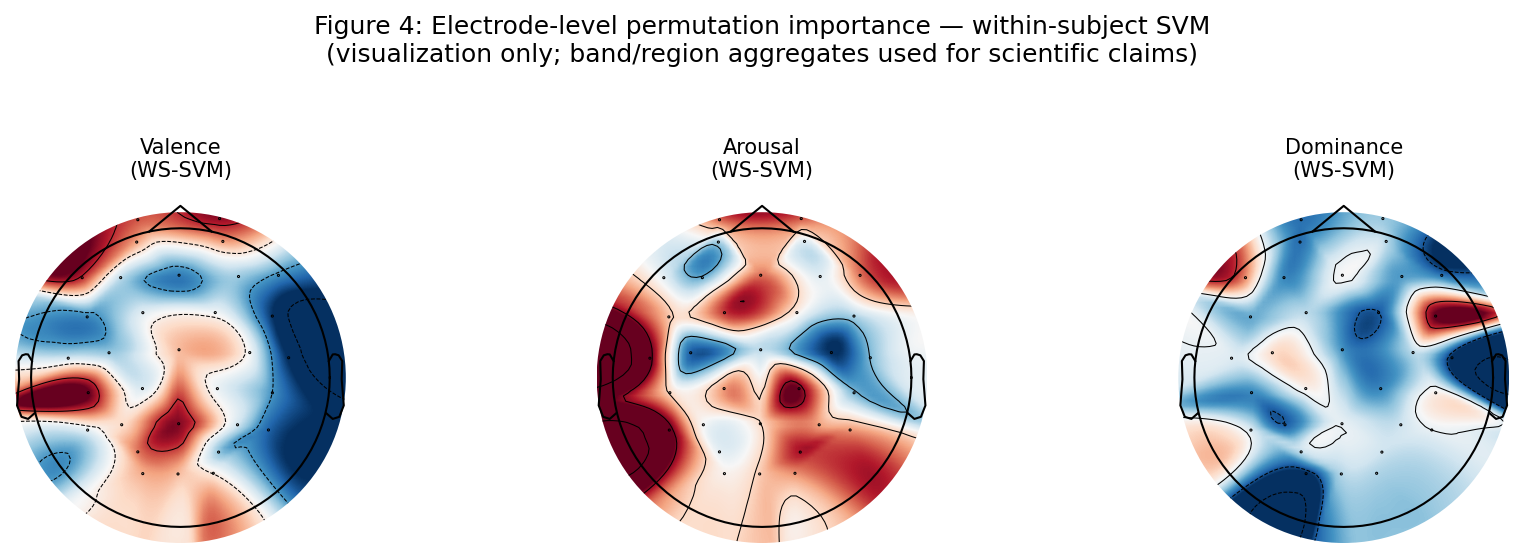

Saved: figure_4_topomaps.png


In [6]:
try:
    import mne
    HAS_MNE = True
except ImportError:
    HAS_MNE = False
    print('MNE not installed — using fallback bar chart for Figure 4.')

# Electrode-level importance from within-subject SVM
ws_svm_electrode = {
    t: ws['importance_agg'][t]['svm']['electrode']  # (32,)
    for t in TARGET_NAMES
}

if HAS_MNE:
    # Standard DEAP 10-20 montage positions
    montage = mne.channels.make_standard_montage('standard_1020')
    info    = mne.create_info(ch_names=CHANNEL_NAMES, sfreq=128, ch_types='eeg')
    info.set_montage(montage, on_missing='ignore')

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, target in zip(axes, TARGET_NAMES):
        imp = ws_svm_electrode[target]
        mne.viz.plot_topomap(
            imp, info, axes=ax, show=False,
            cmap='RdBu_r', vlim=(imp.min(), imp.max()),
            contours=4,
        )
        ax.set_title(f'{target.capitalize()}\n(WS-SVM)', fontsize=10)
    fig.suptitle(
        'Figure 4: Electrode-level permutation importance — within-subject SVM\n'
        '(visualization only; band/region aggregates used for scientific claims)',
        y=1.05
    )
else:
    # Fallback: horizontal bar chart per target
    fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
    for ax, target in zip(axes, TARGET_NAMES):
        imp  = ws_svm_electrode[target]
        rank = np.argsort(imp)[::-1][:16]  # top 16 electrodes
        ax.barh([CHANNEL_NAMES[i] for i in rank], imp[rank],
                color=COLORS[target], alpha=0.8)
        ax.set_title(f'{target.capitalize()} (WS-SVM)')
        ax.set_xlabel('Importance')
        ax.axvline(0, color='gray', linewidth=0.7)
    fig.suptitle(
        'Figure 4: Top-16 electrode importance — within-subject SVM\n'
        '(visualization only; scientific claims use band/region aggregates)',
        y=1.02
    )

plt.tight_layout()
save('figure_4_topomaps')

## Figure 5 — Within-subject SVM band-level importance (RQ1)

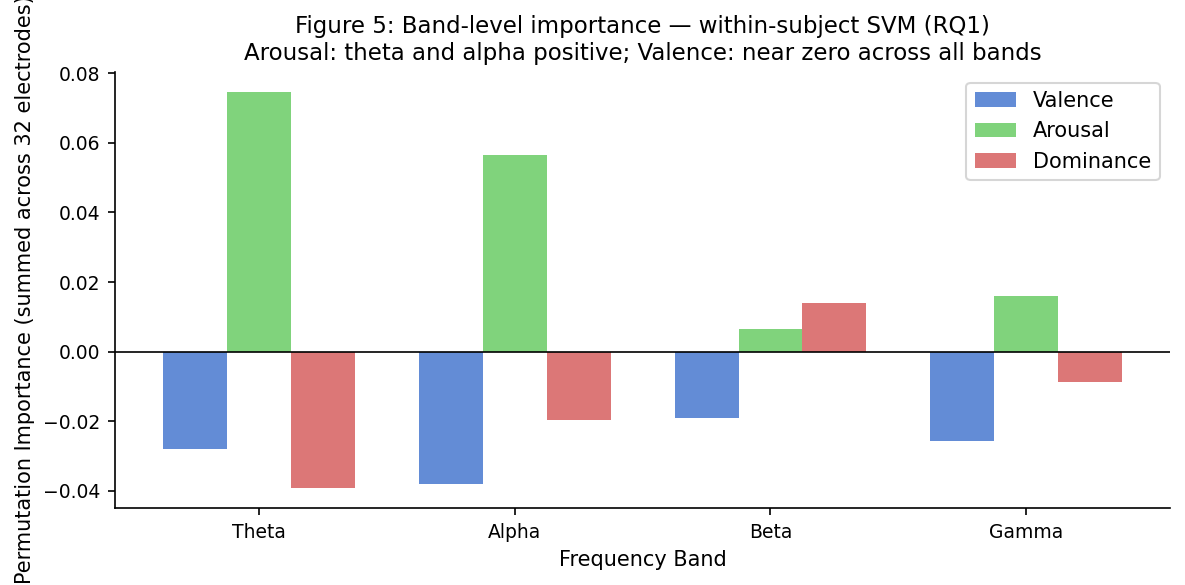

Saved: figure_5_band_importance.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

x     = np.arange(len(BAND_NAMES))
width = 0.25
offsets = [-width, 0, width]

for i, target in enumerate(TARGET_NAMES):
    band_imp = ws['importance_agg'][target]['svm']['band']  # (4,)
    bars = ax.bar(x + offsets[i], band_imp, width,
                  label=target.capitalize(), color=COLORS[target], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([b.capitalize() for b in BAND_NAMES])
ax.set_xlabel('Frequency Band')
ax.set_ylabel('Permutation Importance (summed across 32 electrodes)')
ax.legend()
ax.set_title(
    'Figure 5: Band-level importance — within-subject SVM (RQ1)\n'
    'Arousal: theta and alpha positive; Valence: near zero across all bands'
)

plt.tight_layout()
save('figure_5_band_importance')

## Figure 6 — FAA feature importance ranks (RQ2)

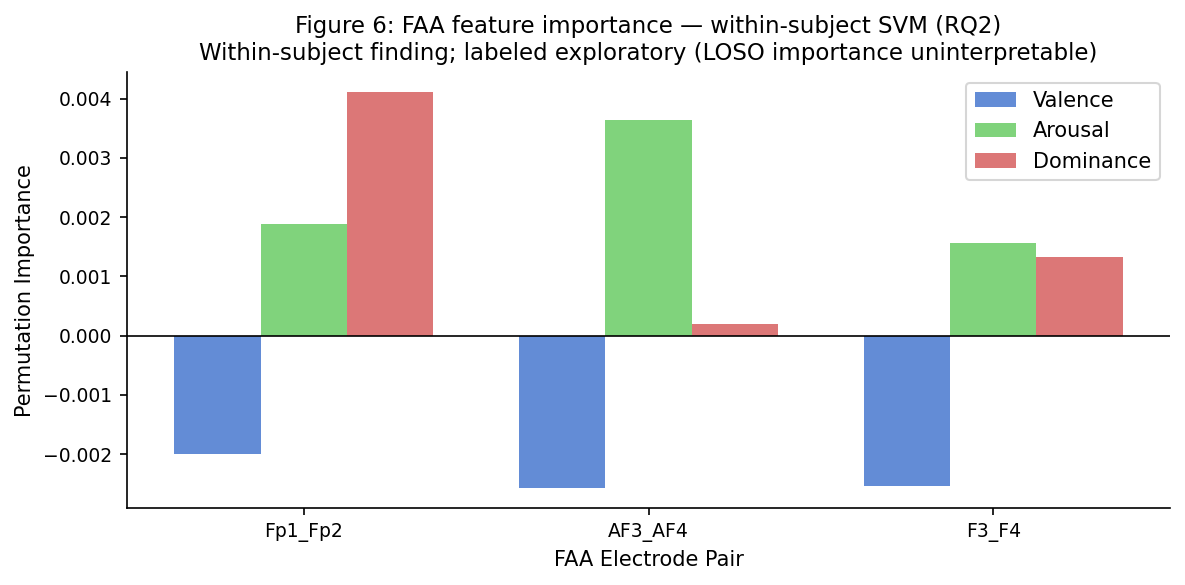

Saved: figure_6_faa_importance.png


In [9]:
# FAA feature indices: last 3 in the 131-feature vector
faa_indices = [128, 129, 130]
faa_labels  = [feat_names[i] for i in faa_indices]

# Within-subject SVM mean importance for FAA features only
faa_imp = {
    t: np.mean(ws['importance_mean'][t]['svm'], axis=0)[faa_indices]
       if ws['importance_mean'][t]['svm'].ndim > 1
       else ws['importance_mean'][t]['svm'][faa_indices]
    for t in TARGET_NAMES
}

fig, ax = plt.subplots(figsize=(8, 4))

x     = np.arange(len(faa_labels))
width = 0.25
offsets = [-width, 0, width]

for i, target in enumerate(TARGET_NAMES):
    ax.bar(x + offsets[i], faa_imp[target], width,
           label=target.capitalize(), color=COLORS[target], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([l.replace('FAA_', '') for l in faa_labels], fontsize=9)
ax.set_xlabel('FAA Electrode Pair')
ax.set_ylabel('Permutation Importance')
ax.legend()
ax.set_title(
    'Figure 6: FAA feature importance — within-subject SVM (RQ2)\n'
    'Within-subject finding; labeled exploratory (LOSO importance uninterpretable)'
)

plt.tight_layout()
save('figure_6_faa_importance')

## Figure 7 — LOSO accuracy: EEG vs peripheral vs combined (RQ4)

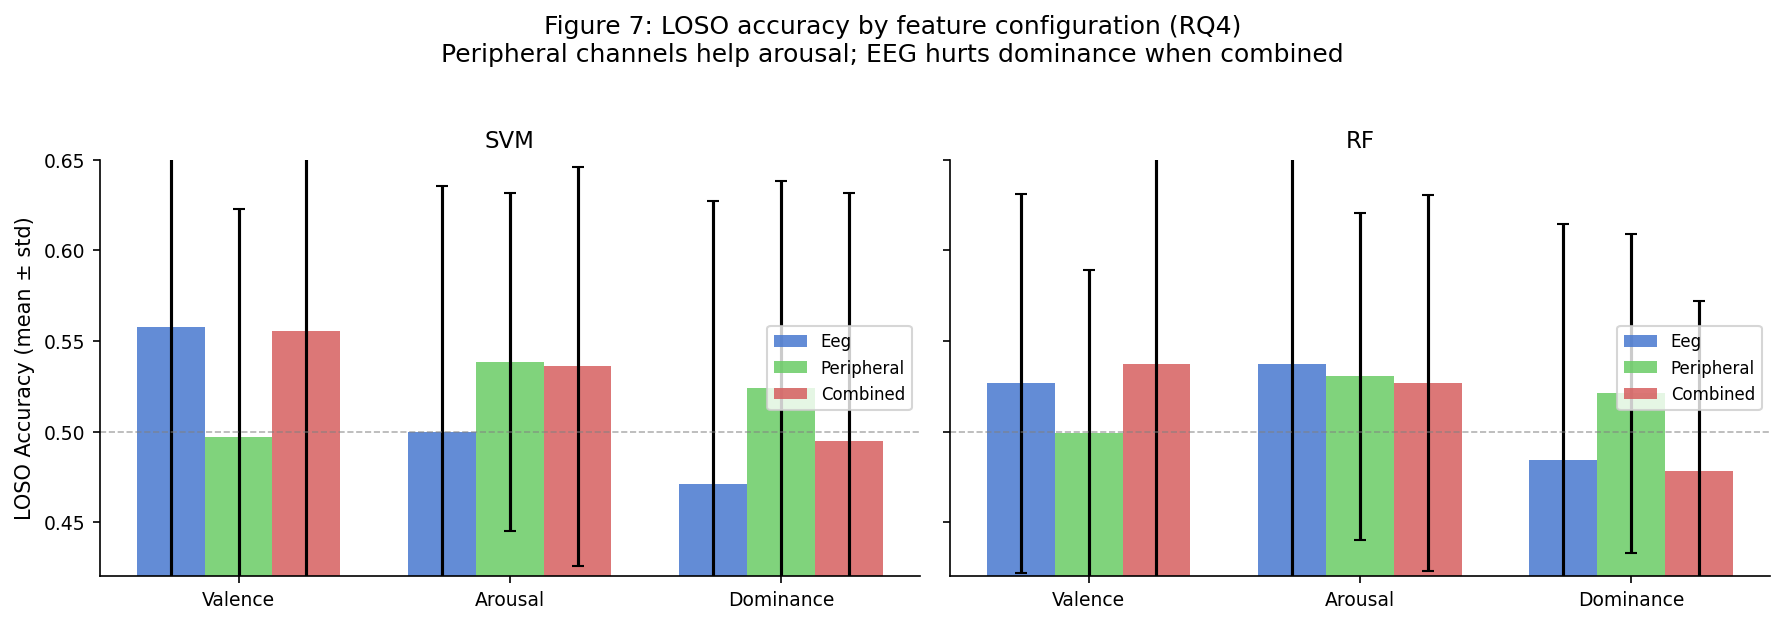

Saved: figure_7_config_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
cfg_colors = {'eeg': '#4878CF', 'peripheral': '#6ACC65', 'combined': '#D65F5F'}

for ax, model in zip(axes, ('svm', 'rf')):
    x     = np.arange(len(TARGET_NAMES))
    width = 0.25
    offsets = [-width, 0, width]

    for i, cfg in enumerate(CONFIGS):
        means = [np.mean(loso['metrics'][t][cfg][model]['acc']) for t in TARGET_NAMES]
        stds  = [np.std( loso['metrics'][t][cfg][model]['acc']) for t in TARGET_NAMES]
        ax.bar(x + offsets[i], means, width, yerr=stds, capsize=3,
               label=cfg.capitalize(), color=cfg_colors[cfg], alpha=0.85)

    ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([t.capitalize() for t in TARGET_NAMES])
    ax.set_title(model.upper())
    ax.set_ylabel('LOSO Accuracy (mean ± std)' if model == 'svm' else '')
    ax.set_ylim(0.42, 0.65)
    ax.legend(fontsize=8)

fig.suptitle(
    'Figure 7: LOSO accuracy by feature configuration (RQ4)\n'
    'Peripheral channels help arousal; EEG hurts dominance when combined',
    y=1.03
)
plt.tight_layout()
save('figure_7_config_comparison')

## Figure 8 — Importance correlation heatmap: all 3 conditions (RQ5)

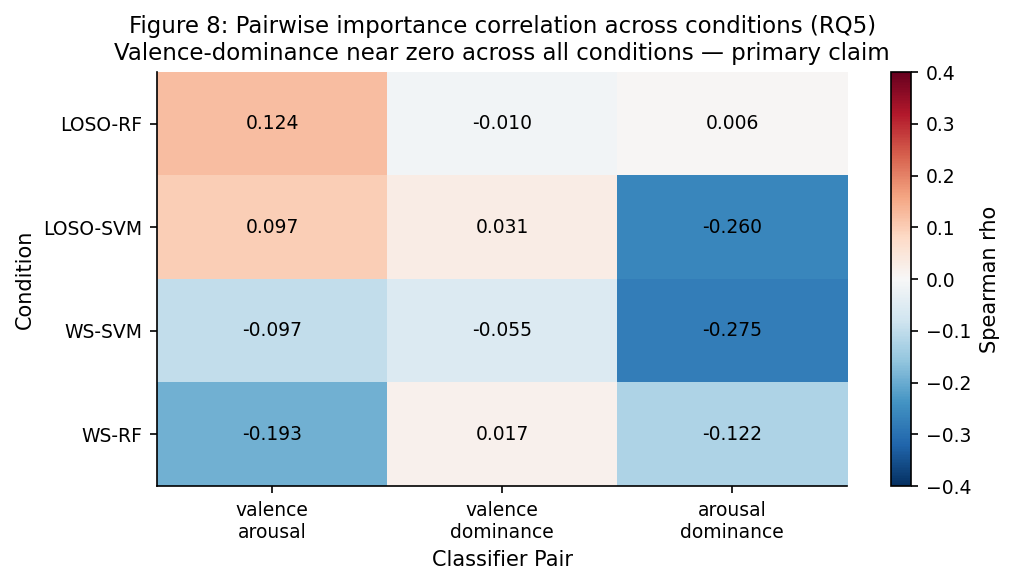

Saved: figure_8_importance_correlation.png


In [11]:
# Three conditions: LOSO-RF, LOSO-SVM, WS-SVM
ws_svm_corr  = ws['importance_corr']['svm']
ws_rf_corr   = ws['importance_corr']['rf']

pairs       = ['valence\narousal', 'valence\ndominance', 'arousal\ndominance']
pair_keys   = ['valence_arousal', 'valence_dominance', 'arousal_dominance']
conditions  = ['LOSO-RF', 'LOSO-SVM', 'WS-SVM', 'WS-RF']

matrix = np.array([
    [rf_corr[k]['rho']      for k in pair_keys],
    [svm_imp['importance_corr'][k]['rho'] for k in pair_keys],
    [ws_svm_corr[k]['rho']  for k in pair_keys],
    [ws_rf_corr[k]['rho']   for k in pair_keys],
])  # (4 conditions, 3 pairs)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(matrix, cmap='RdBu_r', vmin=-0.4, vmax=0.4, aspect='auto')

ax.set_xticks(range(len(pairs)))
ax.set_xticklabels(pairs, fontsize=9)
ax.set_yticks(range(len(conditions)))
ax.set_yticklabels(conditions)
ax.set_xlabel('Classifier Pair')
ax.set_ylabel('Condition')

# Annotate cells with rho values
for i in range(len(conditions)):
    for j in range(len(pairs)):
        ax.text(j, i, f'{matrix[i, j]:.3f}', ha='center', va='center',
                fontsize=9, color='black')

plt.colorbar(im, ax=ax, label='Spearman rho')
ax.set_title(
    'Figure 8: Pairwise importance correlation across conditions (RQ5)\n'
    'Valence-dominance near zero across all conditions — primary claim'
)
plt.tight_layout()
save('figure_8_importance_correlation')

## Figure 9 — Band ablation accuracy heatmap (RQ1 isolation)

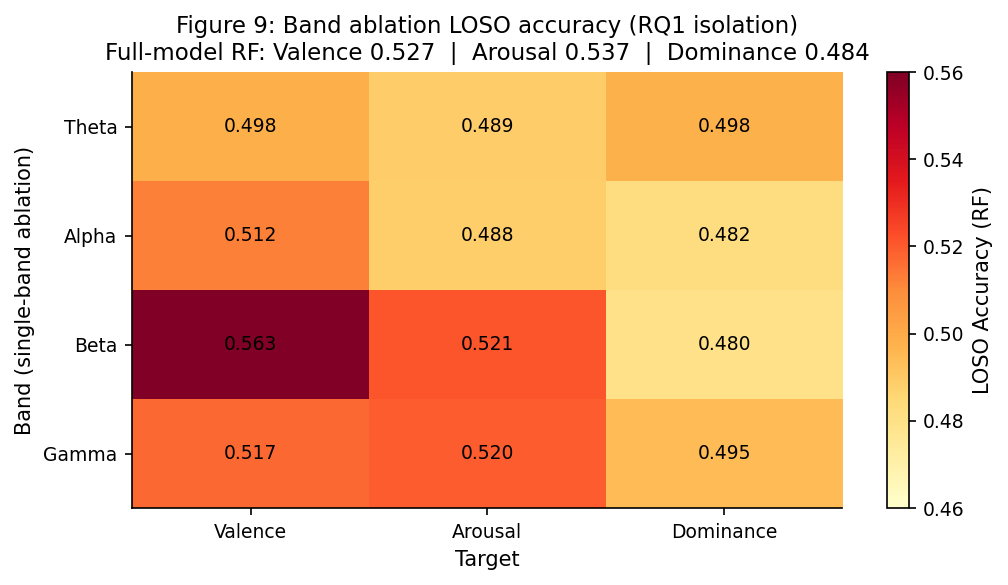

Saved: figure_9_band_ablation.png


In [12]:
# Build (4 bands x 3 targets) ablation accuracy matrix
abl_matrix = np.array([
    [np.mean(loso['ablation'][t][b]['acc']) for t in TARGET_NAMES]
    for b in BAND_NAMES
])  # (4, 3)

full_model_acc = np.array([
    np.mean(loso['metrics'][t]['eeg']['rf']['acc']) for t in TARGET_NAMES
])  # (3,)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(abl_matrix, cmap='YlOrRd', vmin=0.46, vmax=0.56, aspect='auto')

ax.set_xticks(range(len(TARGET_NAMES)))
ax.set_xticklabels([t.capitalize() for t in TARGET_NAMES])
ax.set_yticks(range(len(BAND_NAMES)))
ax.set_yticklabels([b.capitalize() for b in BAND_NAMES])
ax.set_xlabel('Target')
ax.set_ylabel('Band (single-band ablation)')

for i, band in enumerate(BAND_NAMES):
    for j, target in enumerate(TARGET_NAMES):
        ax.text(j, i, f'{abl_matrix[i, j]:.3f}', ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=ax, label='LOSO Accuracy (RF)')

# Full model reference as text below
ref_str = 'Full-model RF: ' + '  |  '.join(
    f'{t.capitalize()} {full_model_acc[i]:.3f}' for i, t in enumerate(TARGET_NAMES)
)
ax.set_title(
    f'Figure 9: Band ablation LOSO accuracy (RQ1 isolation)\n'
    f'{ref_str}'
)
plt.tight_layout()
save('figure_9_band_ablation')

## Figure 10 — Null distribution vs observed importance correlation (RQ5)

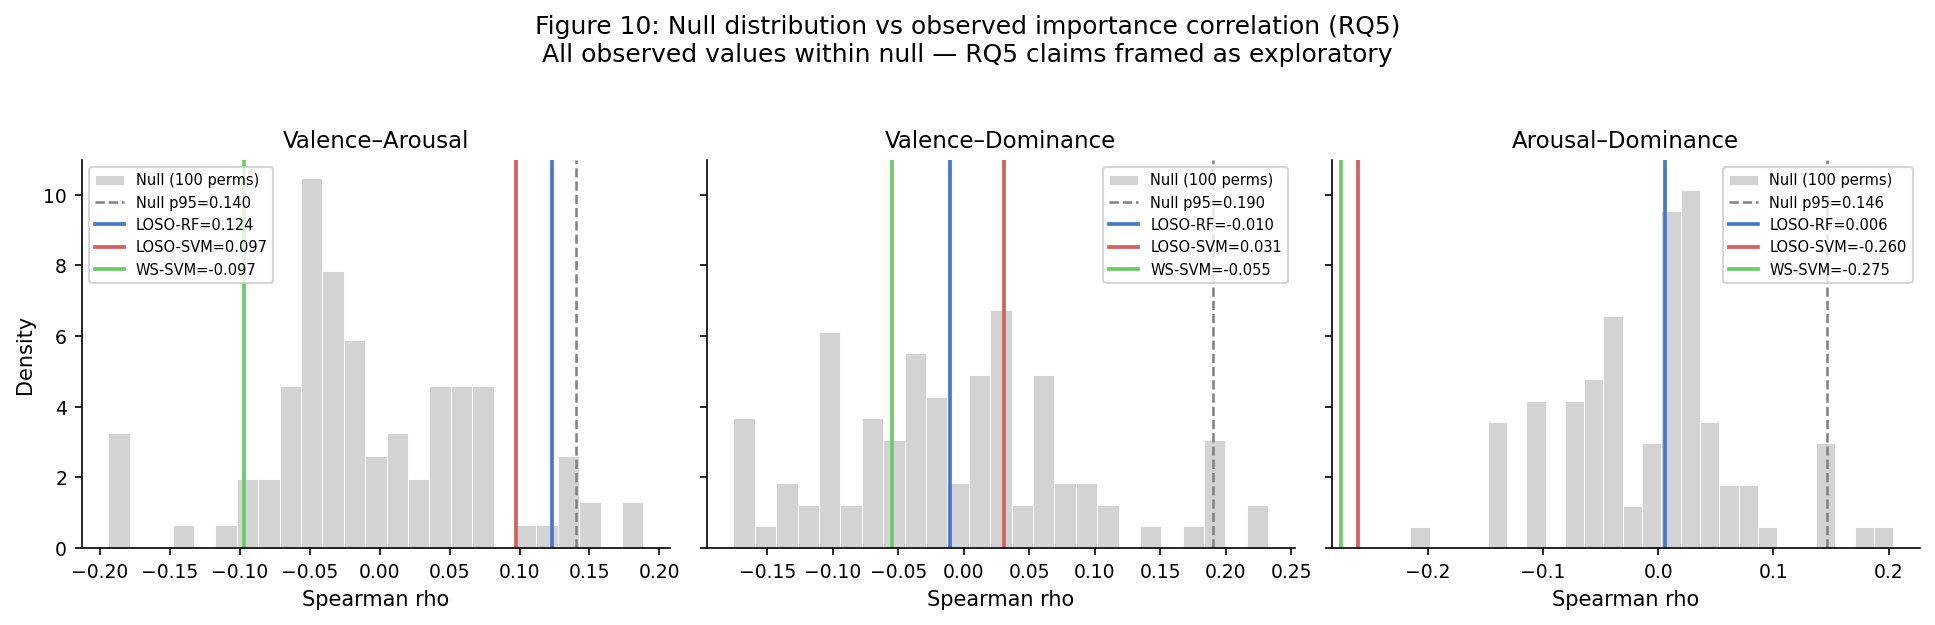

Saved: figure_10_null_distribution.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

pair_labels = {
    'valence_arousal':   'Valence–Arousal',
    'valence_dominance': 'Valence–Dominance',
    'arousal_dominance': 'Arousal–Dominance',
}

# Observed values per condition
observed = {
    'LOSO-RF':  {k: rf_corr[k]['rho'] for k in pair_keys},
    'LOSO-SVM': {k: svm_imp['importance_corr'][k]['rho'] for k in pair_keys},
    'WS-SVM':   {k: ws['importance_corr']['svm'][k]['rho'] for k in pair_keys},
}
obs_colors = {'LOSO-RF': '#4878CF', 'LOSO-SVM': '#D65F5F', 'WS-SVM': '#6ACC65'}

for ax, key in zip(axes, pair_keys):
    null_vals = null['raw']['correlation'][key]
    ax.hist(null_vals, bins=25, color='lightgray', edgecolor='white',
            linewidth=0.4, label='Null (100 perms)', density=True)

    p95 = null['correlation'][key]['p95']
    ax.axvline(p95, color='gray', linewidth=1.2, linestyle='--',
               label=f'Null p95={p95:.3f}')

    for cond, obs_dict in observed.items():
        ax.axvline(obs_dict[key], linewidth=1.8, linestyle='-',
                   color=obs_colors[cond], label=f'{cond}={obs_dict[key]:.3f}')

    ax.set_xlabel('Spearman rho')
    ax.set_ylabel('Density' if key == 'valence_arousal' else '')
    ax.set_title(pair_labels[key])
    ax.legend(fontsize=7)

fig.suptitle(
    'Figure 10: Null distribution vs observed importance correlation (RQ5)\n'
    'All observed values within null — RQ5 claims framed as exploratory',
    y=1.03
)
plt.tight_layout()
save('figure_10_null_distribution')

## Stimulus confound check (Limitations section)

In [14]:
# For each of the 40 trials, compute std of ratings across 32 subjects
# Trials with std < 1.5 are high-stimulus-bias
BIAS_THRESHOLD = 1.5

print('Stimulus confound check (inter-subject label std per trial):')
print(f'Threshold: std < {BIAS_THRESHOLD} = near-unanimous agreement = high stimulus bias')
print()

for target, col in TARGETS.items():
    trial_stds = []
    for trial in range(40):
        trial_mask = np.arange(len(y))[np.arange(len(y)) % 40 == trial]
        trial_stds.append(y[trial_mask, col].std())
    trial_stds = np.array(trial_stds)
    n_biased   = int((trial_stds < BIAS_THRESHOLD).sum())
    print(f'  {target:<12}: {n_biased}/40 high-bias trials '
          f'(std < {BIAS_THRESHOLD})  '
          f'mean std = {trial_stds.mean():.2f}')

print()
print('Document this in paper limitations section regardless of magnitude.')
print('Negative valence LOSO gap (-0.013) is consistent with stimulus confound:')
print('cross-subject patterns from same stimuli provide signal that within-subject CV cannot exploit.')

Stimulus confound check (inter-subject label std per trial):
Threshold: std < 1.5 = near-unanimous agreement = high stimulus bias

  valence     : 16/40 high-bias trials (std < 1.5)  mean std = 1.82
  arousal     : 16/40 high-bias trials (std < 1.5)  mean std = 1.70
  dominance   : 4/40 high-bias trials (std < 1.5)  mean std = 1.90

Document this in paper limitations section regardless of magnitude.
Negative valence LOSO gap (-0.013) is consistent with stimulus confound:
cross-subject patterns from same stimuli provide signal that within-subject CV cannot exploit.


## All figures summary

In [15]:
figs = sorted(Path('../results/figures').glob('figure_*.png'))
print(f'{len(figs)} figures saved to results/figures/:')
for f in figs:
    size_kb = f.stat().st_size // 1024
    print(f'  {f.name}  ({size_kb} KB)')
print('\nReady for Phase 6: Paper Drafting.')

10 figures saved to results/figures/:
  figure_10_null_distribution.png  (148 KB)
  figure_1_class_balance.png  (82 KB)
  figure_2_band_power_heatmap.png  (251 KB)
  figure_3_accuracy_comparison.png  (94 KB)
  figure_4_topomaps.png  (815 KB)
  figure_5_band_importance.png  (122 KB)
  figure_6_faa_importance.png  (111 KB)
  figure_7_config_comparison.png  (117 KB)
  figure_8_importance_correlation.png  (141 KB)
  figure_9_band_ablation.png  (142 KB)

Ready for Phase 6: Paper Drafting.


In [16]:
# Fig 10 check — arousal-dominance left tail significance
p5 = np.percentile(null['raw']['correlation']['arousal_dominance'], 5)
obs_ws_svm = ws['importance_corr']['svm']['arousal_dominance']['rho']

print(f"Null p5:           {p5:.3f}")
print(f"WS-SVM observed:   {obs_ws_svm:.3f}")
print(f"Below null p5:     {obs_ws_svm < p5}")
print()
if obs_ws_svm < p5:
    print("SIGNIFICANT: arousal-dominance WS-SVM falls below null p5.")
    print("Arousal and dominance classifiers use anti-correlated feature sets within subjects.")
    print("Report in RQ5 section as significant negative correlation, not just near-zero.")
else:
    print("Not significant at p5 threshold. Report arousal-dominance as inconclusive as documented.")

Null p5:           -0.144
WS-SVM observed:   -0.275
Below null p5:     True

SIGNIFICANT: arousal-dominance WS-SVM falls below null p5.
Arousal and dominance classifiers use anti-correlated feature sets within subjects.
Report in RQ5 section as significant negative correlation, not just near-zero.
